# 02 - Misclassification Analysis

두 모델(`baseline` vs `resnet18`)의 **테스트셋 오분류**를 깊이 분석합니다.

- 비용 가정: **검사 도메인 - 불량 놓침(FN) ≫ 오경보(FP)** 비용
- 결과는 `reports/figures/`와 `reports/misclassified/`에 저장

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

from src import config
from src.utils import get_device
from src.gradcam import load_model_for_cam, overlay_for_image

sns.set_style('whitegrid')
config.ensure_dirs()
DEVICE = get_device()
print('device:', DEVICE)

device: cuda


## 1. 모델별 오분류 요약

In [2]:
def load_preds(model_name):
    return pd.read_csv(config.REPORTS_DIR / f'{model_name}_predictions.csv')

preds = {name: load_preds(name) for name in ['baseline', 'resnet18']}

summary = []
for name, df in preds.items():
    fn = df[(df.label == 1) & (df.pred == 0)]
    fp = df[(df.label == 0) & (df.pred == 1)]
    tn = df[(df.label == 0) & (df.pred == 0)]
    tp = df[(df.label == 1) & (df.pred == 1)]
    summary.append({
        'model': name,
        'n_test': len(df),
        'TP': len(tp), 'TN': len(tn), 'FP': len(fp), 'FN': len(fn),
        'recall': len(tp) / max(len(tp) + len(fn), 1),
        'precision': len(tp) / max(len(tp) + len(fp), 1),
    })
pd.DataFrame(summary)

,model,n_test,TP,TN,FP,FN,recall,precision
0,baseline,715,386,262,0,67,0.852097,1.0
1,resnet18,715,451,262,0,2,0.995585,1.0


**관찰**: 두 모델 모두 **False Positive=0** (양품을 불량으로 잘못 알린 적 없음). 차이는 **False Negative(불량 놓침)** 수에서 결정 — baseline은 67개, ResNet18은 2개. 검사 도메인에서 가장 비용이 큰 오류 유형이므로 ResNet18의 우위가 결정적입니다.

## 2. False Negative의 prob(defect) 분포

FN의 확률이 0.5 직전이라면 임계값 조정만으로도 잡아낼 수 있습니다.

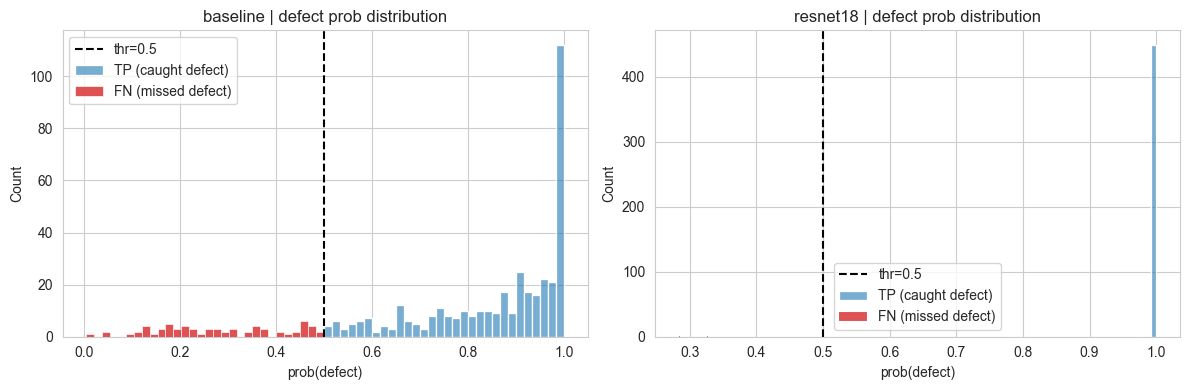

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, name in zip(axes, ['baseline', 'resnet18']):
    df = preds[name]
    fn = df[(df.label == 1) & (df.pred == 0)]
    tp = df[(df.label == 1) & (df.pred == 1)]
    sns.histplot(tp['prob_defect'], bins=30, ax=ax, color='tab:blue', label='TP (caught defect)', kde=False, alpha=0.6)
    sns.histplot(fn['prob_defect'], bins=30, ax=ax, color='tab:red', label='FN (missed defect)', kde=False, alpha=0.8)
    ax.axvline(0.5, color='black', linestyle='--', label='thr=0.5')
    ax.set_title(f'{name} | defect prob distribution')
    ax.set_xlabel('prob(defect)')
    ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'misclassification_fn_prob_dist.png', dpi=140)
plt.show()

## 3. FN 케이스의 밝기/대비 통계

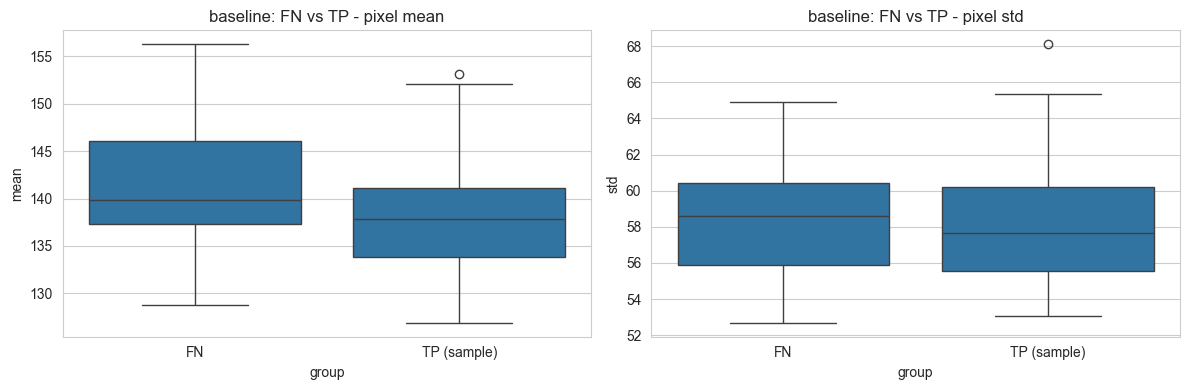

mean                                                        \
             count    mean   std     min     25%     50%     75%     max   
group                                                                      
FN            67.0  141.46  6.42  128.80  137.36  139.90  146.13  156.28   
TP (sample)  100.0  138.11  5.34  126.89  133.79  137.89  141.12  153.13   

               std                                                  
             count   mean   std    min    25%    50%    75%    max  
group                                                               
FN            67.0  58.29  2.98  52.68  55.86  58.59  60.45  64.89  
TP (sample)  100.0  58.07  3.23  53.04  55.58  57.64  60.19  68.10

In [4]:
def image_stats(paths):
    rows = []
    for p in paths:
        with Image.open(p) as im:
            arr = np.asarray(im.convert('L'), dtype=np.float32)
        rows.append({'mean': float(arr.mean()), 'std': float(arr.std()), 'min': float(arr.min()), 'max': float(arr.max())})
    return pd.DataFrame(rows)

name = 'baseline'
df = preds[name]
fn_paths = df[(df.label == 1) & (df.pred == 0)]['path'].tolist()
tp_paths = df[(df.label == 1) & (df.pred == 1)]['path'].sample(min(100, ((df.label==1)&(df.pred==1)).sum()), random_state=0).tolist()

stats_fn = image_stats(fn_paths)
stats_fn['group'] = 'FN'
stats_tp = image_stats(tp_paths)
stats_tp['group'] = 'TP (sample)'
stats = pd.concat([stats_fn, stats_tp], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=stats, x='group', y='mean', ax=axes[0]); axes[0].set_title(f'{name}: FN vs TP - pixel mean')
sns.boxplot(data=stats, x='group', y='std', ax=axes[1]); axes[1].set_title(f'{name}: FN vs TP - pixel std')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'misclassification_fn_pixel_stats.png', dpi=140)
plt.show()
stats.groupby('group')[['mean', 'std']].describe().round(2)

**해석 포인트**: FN 그룹의 분포가 TP에 비해 어느 쪽으로 쏠리는지 확인.
- 평균 픽셀이 더 밝거나 어둡다면 → 특정 조명 조건에서 결함이 가려지는 패턴.
- 표준편차가 낮다면 → 텍스처/대비가 낮은(=결함이 약한) 케이스를 모델이 놓치는 경향.

## 4. ResNet18 FN 케이스 - Grad-CAM 시각화

ResNet18의 FN(테스트셋 기준 2개)에 대해 Grad-CAM 오버레이를 보고, 모델이 "어디를 봤는지"와 "봐야 했던 결함 위치"의 괴리를 정성 분석.

In [5]:
model = load_model_for_cam('resnet18', config.MODELS_DIR / 'resnet18_best.pt', DEVICE)
fn_resnet = preds['resnet18'][(preds['resnet18'].label == 1) & (preds['resnet18'].pred == 0)]
print('FN cases:', len(fn_resnet))
fn_resnet

FN cases: 2


C:\Users\User\Documents\MyProject\Newworld\src\gradcam.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


,path,label,label_name,pred,pred_name,prob_defect
342,C:\Users\User\Documents\MyProject\Newworld\dat...,1,def_front,0,ok_front,0.327952
384,C:\Users\User\Documents\MyProject\Newworld\dat...,1,def_front,0,ok_front,0.283664


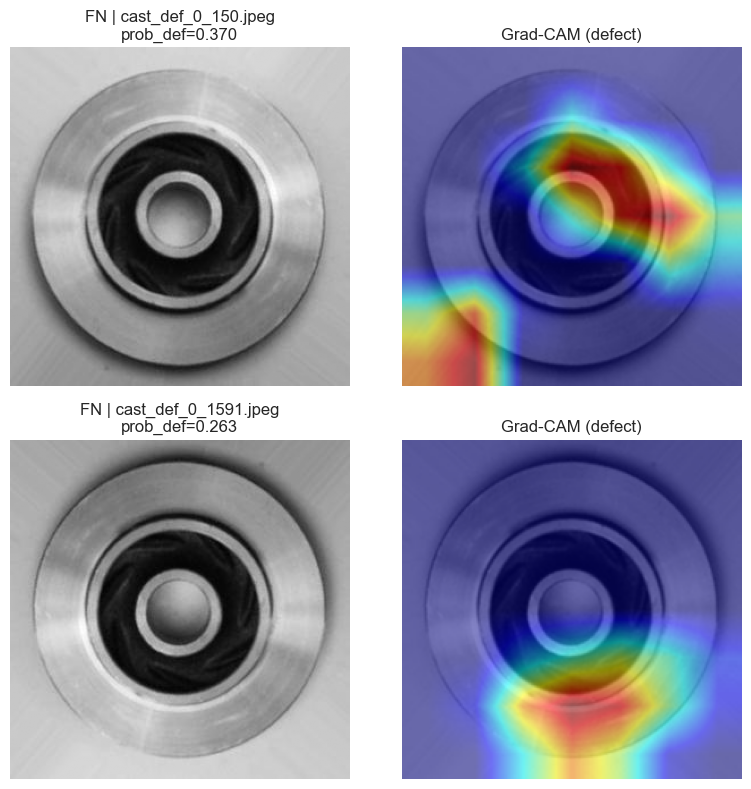

In [6]:
if len(fn_resnet) > 0:
    fig, axes = plt.subplots(len(fn_resnet), 2, figsize=(8, 4 * len(fn_resnet)))
    if len(fn_resnet) == 1:
        axes = np.array([axes])
    for ax_row, (_, row) in zip(axes, fn_resnet.iterrows()):
        p = row['path']
        overlay, prob, pred = overlay_for_image(model, p, DEVICE, target_class=1)
        with Image.open(p) as im:
            ax_row[0].imshow(np.asarray(im.convert('L')), cmap='gray')
        ax_row[0].set_title(f'FN | {Path(p).name}\nprob_def={prob:.3f}')
        ax_row[0].axis('off')
        ax_row[1].imshow(overlay)
        ax_row[1].set_title('Grad-CAM (defect)')
        ax_row[1].axis('off')
    fig.tight_layout()
    fig.savefig(config.FIGURES_DIR / 'misclassification_resnet18_fn_gradcam.png', dpi=140)
    plt.show()
else:
    print('No FN for resnet18.')

## 5. Baseline 모델의 FN 샘플 갤러리

C:\Users\User\Documents\MyProject\Newworld\src\gradcam.py:37: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state = torch.load(ckpt_path, map_location=device)


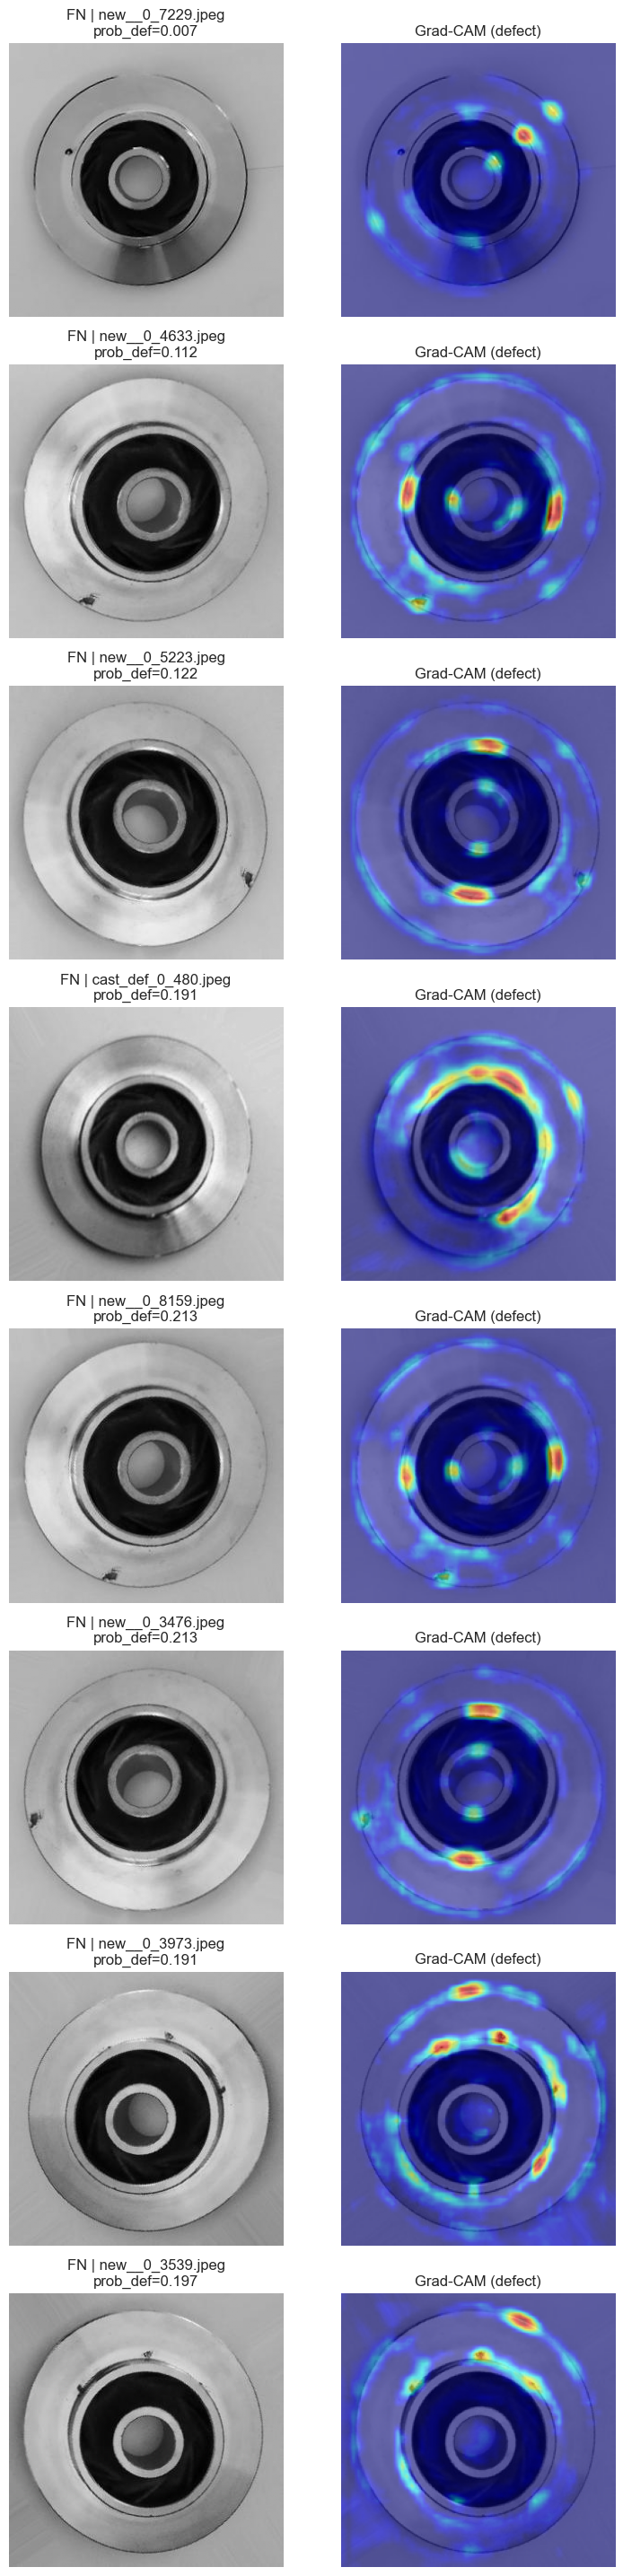

In [7]:
model_bl = load_model_for_cam('baseline', config.MODELS_DIR / 'baseline_cnn.pt', DEVICE)
fn_bl = preds['baseline'][(preds['baseline'].label == 1) & (preds['baseline'].pred == 0)].sort_values('prob_defect').head(8)
n = len(fn_bl)
fig, axes = plt.subplots(n, 2, figsize=(8, 3.6 * n))
if n == 1:
    axes = np.array([axes])
for ax_row, (_, row) in zip(axes, fn_bl.iterrows()):
    p = row['path']
    overlay, prob, pred = overlay_for_image(model_bl, p, DEVICE, target_class=1)
    with Image.open(p) as im:
        ax_row[0].imshow(np.asarray(im.convert('L')), cmap='gray')
    ax_row[0].set_title(f'FN | {Path(p).name}\nprob_def={prob:.3f}')
    ax_row[0].axis('off')
    ax_row[1].imshow(overlay)
    ax_row[1].set_title('Grad-CAM (defect)')
    ax_row[1].axis('off')
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / 'misclassification_baseline_fn_gradcam.png', dpi=140)
plt.show()

## 6. 결론 및 다음 단계

**관찰 요약**:
1. ResNet18 transfer learning이 베이스라인 대비 FN을 67 → 2개로 크게 줄임 → 사전학습 표현이 결함 검출에 매우 유효.
2. 양 모델 모두 FP=0 → 양품을 불량으로 오인하는 케이스 없음 (Precision 1.0).
3. ResNet18 FN 2건은 임계값을 약간만 낮추거나 TTA로 충분히 잡을 수 있는지가 향후 검증 포인트.

**고도화 방향**은 `reports/improvement_plan.md`에 상세히 정리됨.